# About the dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn import metrics
import os
import warnings
warnings.filterwarnings("ignore")

-----------
# Inspecting the dataset

In [4]:
IMG_SHAPE = (128, 128)
BATCH_SIZE = 32

In [5]:
data = image_dataset_from_directory('diebetics_retina',
                                    image_size= IMG_SHAPE,
                                    color_mode= 'rgb',
                                    batch_size= BATCH_SIZE,
                                    shuffle= True,
                                    seed = 2022
                                   )

Found 4217 files belonging to 4 classes.


In [6]:
print("Total number of batches: ",len(data))

Total number of batches:  132


## Displaying data distribution

In [7]:
class_names = data.class_names
for idx, name in enumerate(class_names):
  print(f"{idx} = {name}", end=", ")

0 = cataract, 1 = diabetic_retinopathy, 2 = glaucoma, 3 = normal, 

In [8]:
NO_CLASSES = len(class_names)
print("Number of classes = ", NO_CLASSES)

Number of classes =  4


In [9]:
labels = np.concatenate([y for x,y in data], axis=0)

In [10]:
values = pd.Series(labels).value_counts().sort_index()
values

0    1038
1    1098
2    1007
3    1074
Name: count, dtype: int64

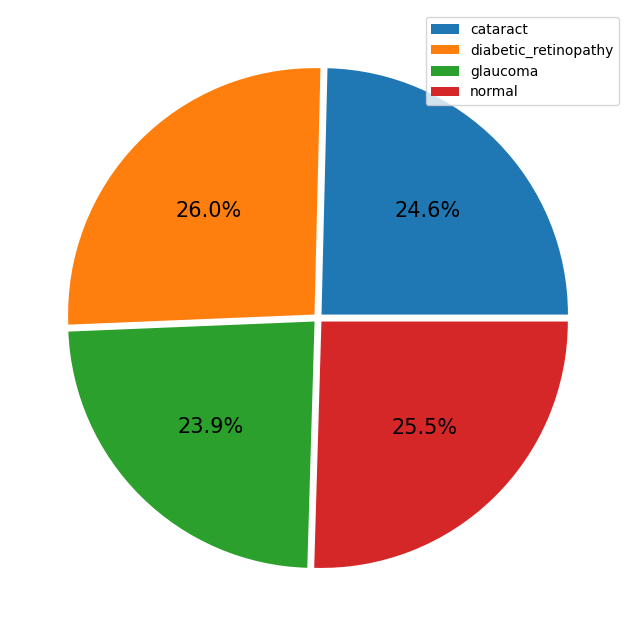

In [11]:
plt.figure(figsize=(12,8))
plt.pie(values,autopct='%1.1f%%', explode = [0.02] * len(values), textprops = {"fontsize":15})
plt.legend(labels=data.class_names)
plt.show()

### The dataset is distributed equally among both classes and is perfectly balanced

-----------

## Getting a data generator to explore the data

In [12]:
data_iterator = data.as_numpy_iterator()

In [13]:
batch = data_iterator.next()

### Each batch contains 256 images of size 100x100

In [14]:
batch[0].shape

(32, 128, 128, 3)

## Displaying some images

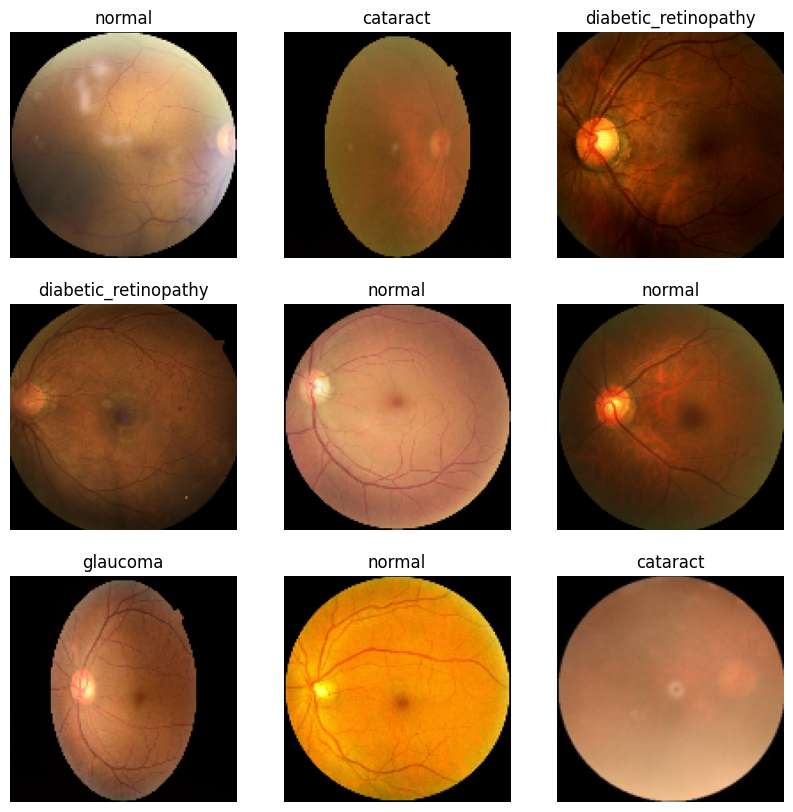

In [15]:
plt.figure(figsize=(10, 10))
for images, label in data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[label[i]])
        plt.axis("off")

### As seen in the images above the parasitized images have a purple colored structure which is the parasite afftected region in the red blood cell. These structures can have a varried shapes and sizes like a ring or oval structure. These ring like structures, their shape, size and the change in color after the staining process helps in determining the parasite species the cell is infected by

-------------

# Images preprocessing

## Standardizing the images
Standardization brings the pixel intensity values to the range of 0-1 such that the data points follow a **gaussian distribution** with mean of zero and standard deviation of one.

Standardizing data includes them in the same range as our **activation functions**, usually between 0 and 1. This allows for less frequent non-zero gradients during training, and therefore the neurons in our network will learn faster.

In [16]:
data = data.map(lambda x, y: (x/255., y))

In [17]:
sample = data.as_numpy_iterator().next()

In [18]:
print(sample[0].min())
print(sample[0].max())

0.0
1.0


## Class weights
Most machine learning algorithms are not very useful with biased class data. But, we can modify the current training algorithm to take into account the skewed distribution of the classes. This can be achieved by giving different weights to both the majority and minority classes. The difference in weights will influence the classification of the classes during the training phase. The whole purpose is to penalize the misclassification made by the minority class by setting a higher class weight and at the same time reducing weight for the majority class.

In [19]:
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(labels),
    y = labels
)

class_weights = {}
for idx, weight in enumerate(weights):
    class_weights[idx] = weight
class_weights

{0: np.float64(1.015655105973025),
 1: np.float64(0.9601548269581056),
 2: np.float64(1.0469215491559087),
 3: np.float64(0.9816108007448789)}

-------------

In [25]:
print("Total number of batchs = ",len(data))

Total number of batchs =  66


In [20]:
train_size = int(0.75 * len(data)) +1
val_size = int(0.10 * len(data))
test_size = int(0.15 * len(data))

In [21]:
train = data.take(train_size)
remaining = data.skip(train_size)
val = remaining.take(val_size)
test = remaining.skip(val_size)

In [22]:
print(f"# train batchs = {len(train)}, # validate batchs = {len(val)}, # test batch = {len(test)}")
len(train) + len(val) + len(test)

# train batchs = 100, # validate batchs = 13, # test batch = 19


132

-------------

# Data augmentation
The term Augmentation refers to making something larger in size. In the context of data, we try to increase the size of the dataset by creating more transformed copies of the original data. This process **increases the diversity in the dataset**. Such transformed images help to make the model more robust in handling the real-time images and increase the generalizability of the system. In the context of bio-medical image data, the samples differ from case to case basis. A similar health condition can form a completely different Whole Slide Image. Thus, a deep learning model should be **robust enough and be able to generalize** on any pattern of the slide image being fed.

Although our data is balanced, but we will randomly transform our data to increase diversity using Keras augmentatin layers, augmentaions like **flipping, rotation, translation, illumination, shift, zooming,** etc... This enables the model to learn all the variations in these data, increasing the accuracy, robustness and also help to reduce overfitting which often becomes the case with lesser data.

In [23]:
def display_aug(strategy, image):
    # Original Image
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title('Original Image')
    plt.show()

    # Augmented Image
    plt.figure(figsize=(10, 10))
    plt.title('Augmented Image')
    for i in range(6):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(strategy(batch[0][0]))
        plt.axis("off")

In [24]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *

In [25]:
flip = RandomFlip("horizontal_and_vertical")
trans = RandomTranslation(0.2, 0.2)
rot = RandomRotation(0.2)
zoom = RandomZoom(0.3)
contrast = RandomContrast(0.3)

In [26]:
gen = train.as_numpy_iterator()
batch = gen.next()
img = batch[0][0]

## Random Flipping (horiziontally and vertically)

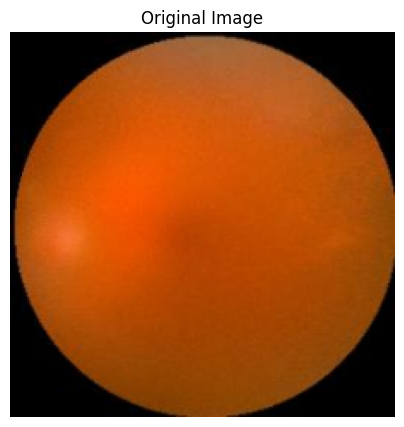

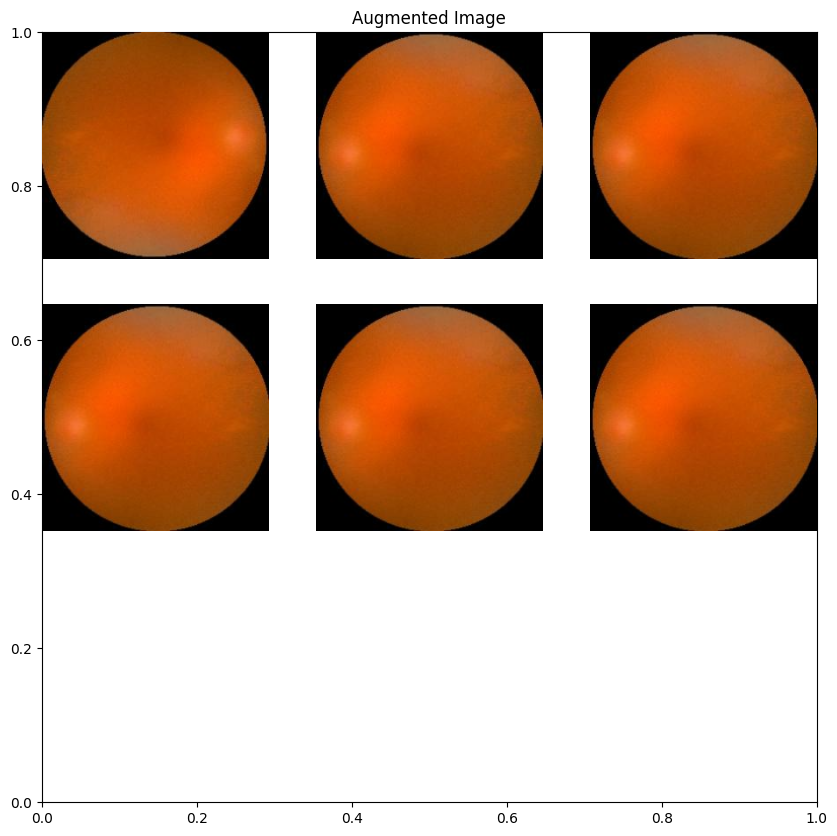

In [33]:
display_aug(flip, img)

## Random Translation (shifting)

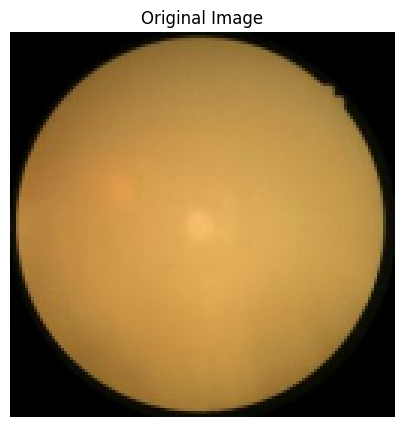

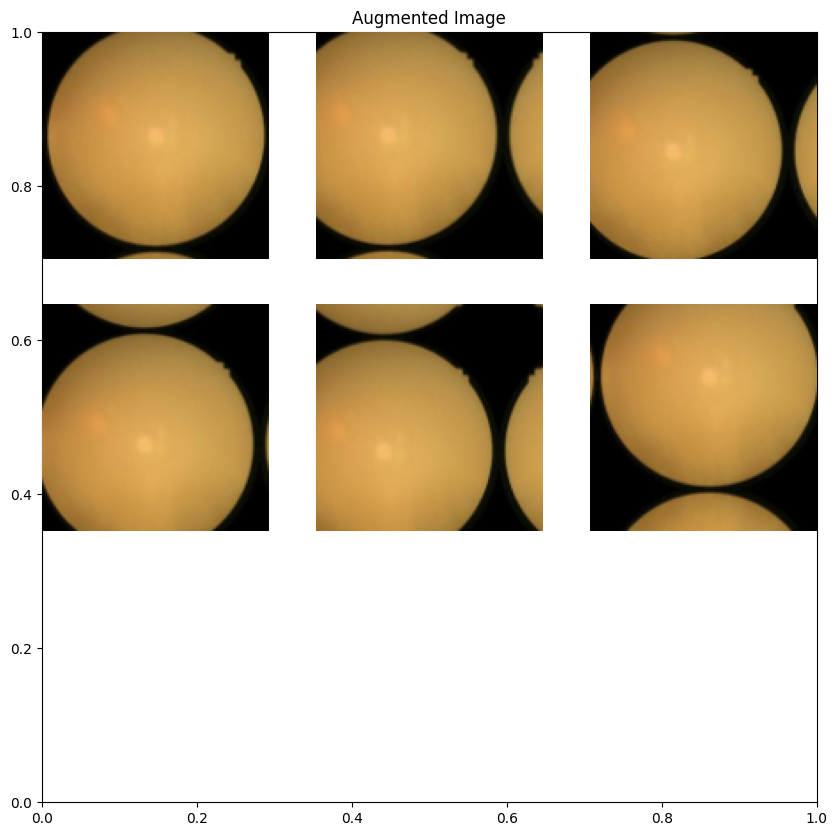

In [27]:
display_aug(trans, img)

## Random Rotation

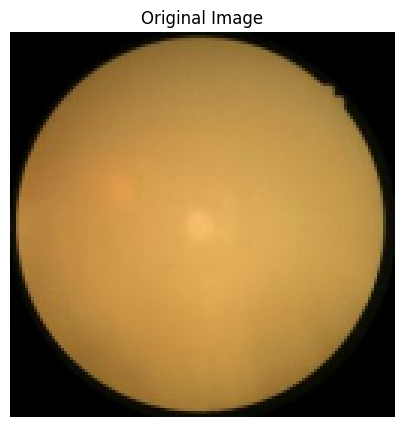

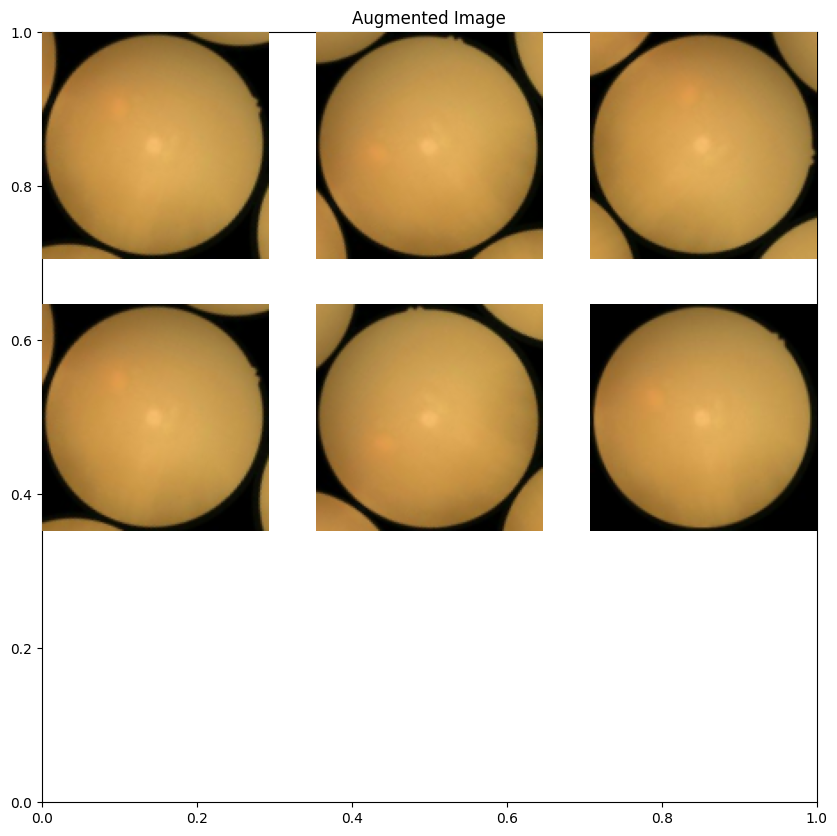

In [28]:
display_aug(rot, img)

## Random Zoom

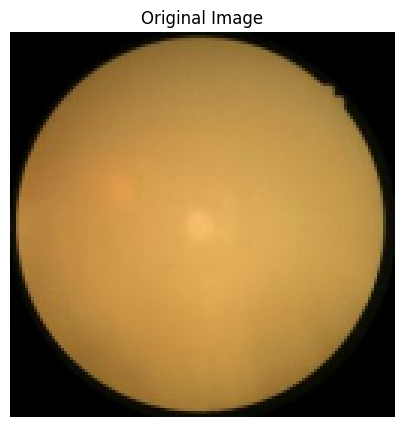

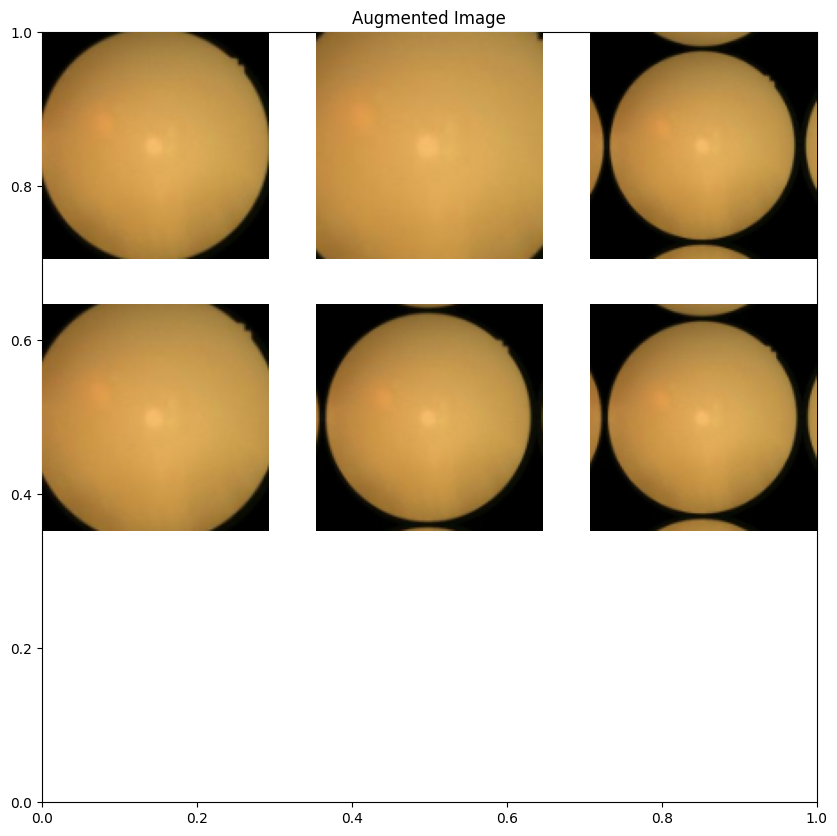

In [29]:
display_aug(zoom, img)

## Random Illumination (Contrast)

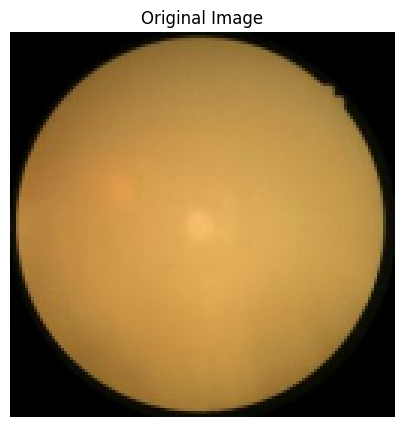

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0165067].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0049722].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0402565].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.047799].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0852339].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0791272].


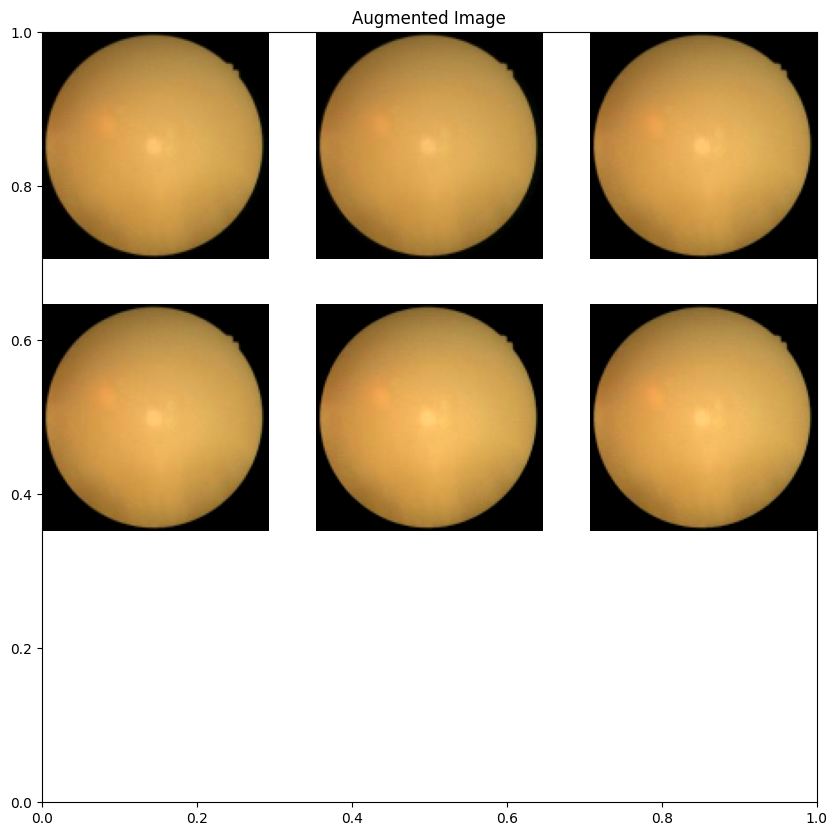

In [30]:
display_aug(contrast, img)

## All at once

In [31]:
data_aug = Sequential(
    [
        Input(shape=IMG_SHAPE + (3,)),
        RandomFlip("horizontal_and_vertical"),
        RandomTranslation(0.2, 0.2),
        RandomRotation(0.2),
        RandomZoom(0.2),
        RandomContrast(0.3),
    ],
    name="augmentation"
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0396769].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0364299].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0420638].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0527302].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.118401].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0284411].


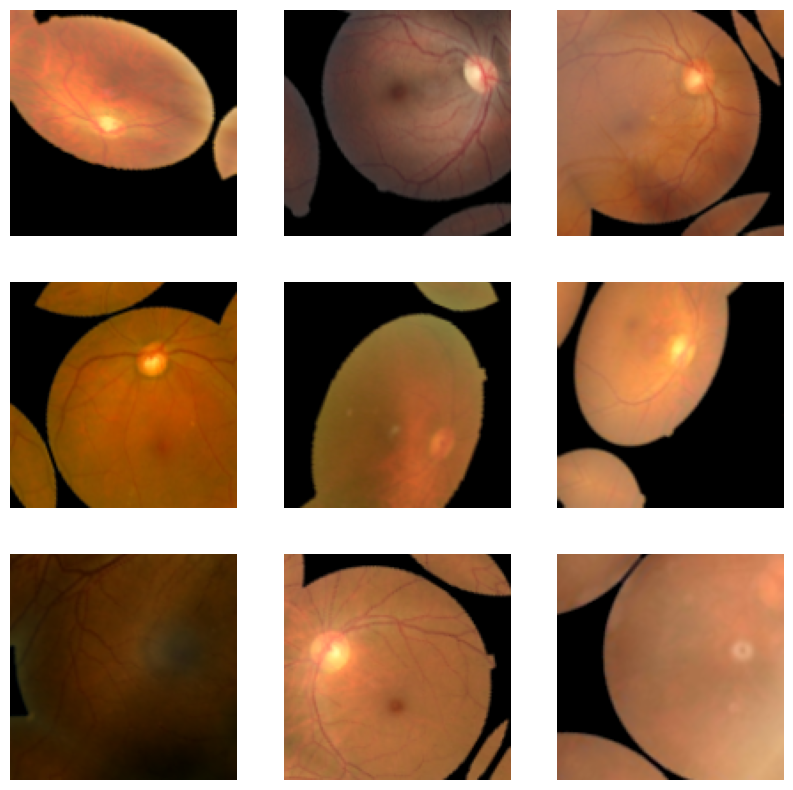

In [32]:
gen = train.as_numpy_iterator()
batch = gen.next()

images = batch[0][:9]
augmented_batch = data_aug(images)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    arr = augmented_batch[i].numpy()

    if arr.min() < 0:                      # e.g. [-1, 1] range (InceptionV3-style preprocessing)
        arr = (arr + 1) / 2.0
    elif arr.max() > 1.5:                   # e.g. [0, 255] range
        arr = arr / 255.0
    # else: already [0, 1], use as-is

    plt.imshow(arr)
    plt.axis("off")
plt.show()

--------------

# Modelling


In [33]:
# Displaying history loss/accuracy
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_his(history):
    plt.figure(figsize=(15,12))
    metrics = ['accuracy', 'loss']
    for i, metric in enumerate(metrics):
        plt.subplot(220+1+i)
        plt.plot(history.epoch, history.history[metric], color=colors[0], label='Train')
        plt.plot(history.epoch, history.history['val_'+metric],
                 color=colors[1], linestyle="--", label='Val')
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.legend()
    plt.show()

In [39]:
from keras.applications.mobilenet_v2 import MobileNetV2
from keras import regularizers,Sequential, Input

from keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout,
    RandomFlip, RandomTranslation, RandomRotation, RandomZoom, RandomContrast
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

def make_model():
    model_base = MobileNetV2(include_top=False, weights="imagenet")

    model = Sequential(name='Transfer_Learning_MobileNetV2')
    model.add(Input((IMG_SHAPE[0], IMG_SHAPE[1], 3)))

    model.add(model_base)

    model.add(GlobalAveragePooling2D(name="GAP"))
    model.add(Dense(1024, kernel_initializer=tf.keras.initializers.HeNormal(), activation='relu', name='fc'))

    model.add(Dropout(0.3, name="dropout_out"))

    model.add(Dense(4, activation='softmax', name="fc_out"))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [40]:
model = make_model()

In [41]:
model.summary()

Model: "Transfer_Learning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_out (Dropout)           │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_out (Dense)                  │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,573,828 (13.63 MB)

 Trainable params: 3,539,716 (13.50 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [42]:
train_aug = train.map(lambda x, y: (data_aug(x, training=True), y))

In [43]:
from keras import callbacks 
Learning_Rate = callbacks.ReduceLROnPlateau(
    monitor = 'val_loss', factor = 0.5, patience = 2, cooldown = 1, verbose = 1
)
Early_Stop = callbacks.EarlyStopping(
    monitor = 'val_loss', patience = 20, verbose = 1, mode = 'auto',restore_best_weights=True
)

## Training the model

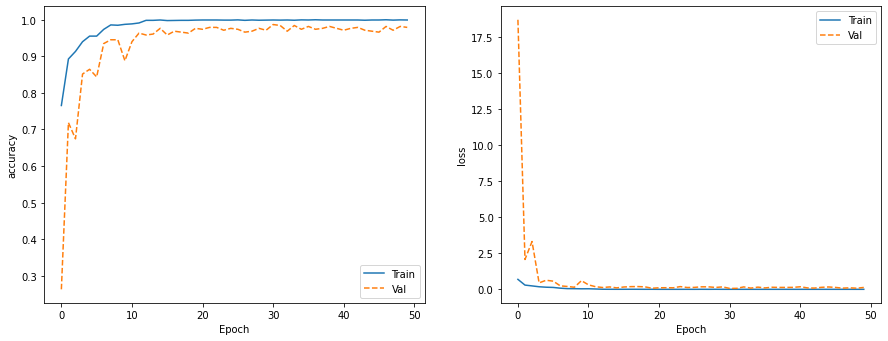

In [ ]:
plot_his(history)

----------